# Problem 3: 
A portfolio with a risky and safe asset

Setup: import packages and load the model with default parameters


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from PortfolioModel import PortfolioModelClass

model = PortfolioModelClass()
print(model)

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026


## Testing trade()

Quick sanity check of the trading rule before using it inside the simulator. 
With theta_star=0.50 and delta=0.10, shares more than 0.10 away from the target should be tracked to 0.50; shares withing the band should be left unchanged. 

In [44]:
theta_test=np.array([0.3,0.5,0.65,0.9])
theta_post,traded=model.trade(theta_test)
print(theta_post)
print(traded)


[0.5 0.5 0.5 0.5]
[0.2  0.   0.15 0.4 ]


# Question 1: Returns

**1. Draw the returns**

Draw $\varepsilon_t$ for all periods and all portfolios in one array of shape $(N,T)$ using the given seed, and compute $R_t$.

In [ ]:
R=model.draw_returns()

**2. Compare with $\mu$ and $\sigma$**
Report the mean and standard deviation of $\log R_t$ across all draws and compare with $\mu$ and $\sigma$. Report the mean of $R_t$ and compare with $\exp(\mu + \tfrac{1}{2}\sigma^2)$.

In [46]:
logR = np.log(R)
print(f"Mean of log R:  {logR.mean():.4f}  (mu = {model.par.mu:.4f})")
print(f"Std of log R:   {logR.std():.4f}  (sigma = {model.par.sigma:.4f})")
print(f"Mean of R:      {R.mean():.4f}  (exp(mu + 0.5*sigma^2) = {np.exp(model.par.mu + 0.5*model.par.sigma**2):.4f})")

Mean of log R:  0.0500  (mu = 0.0500)
Std of log R:   0.2000  (sigma = 0.2000)
Mean of R:      1.0725  (exp(mu + 0.5*sigma^2) = 1.0725)


**3. Figure: distribution of $R_t$ and value of 1 invested**

A histogram of $R_t$, and the value of 1 invested in the risky asset for 20 portfolios vs. the safe asset, on a log scale.

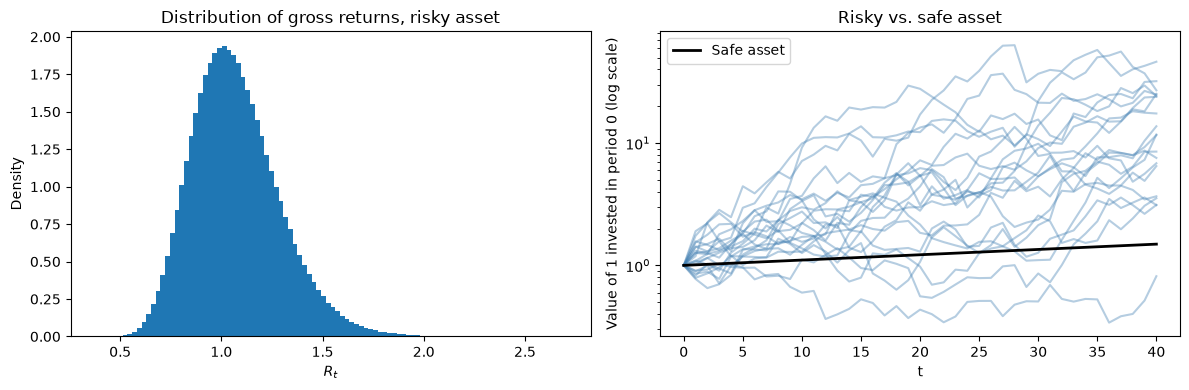

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(R.flatten(), bins=100, density=True)
axes[0].set_xlabel('$R_t$')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of gross returns, risky asset')

value_risky = np.hstack([np.ones((20, 1)), np.cumprod(R[:20, :], axis=1)])
Rf = np.exp(model.par.r)
t_grid = np.arange(model.par.T + 1)
value_safe = Rf**t_grid

for i in range(20):
    axes[1].plot(t_grid, value_risky[i, :], color='steelblue', alpha=0.4)
axes[1].plot(t_grid, value_safe, color='black', linewidth=2, label='Safe asset')
axes[1].set_yscale('log')
axes[1].set_xlabel('t')
axes[1].set_ylabel('Value of 1 invested in period 0 (log scale)')
axes[1].set_title('Risky vs. safe asset')
axes[1].legend()

fig.tight_layout()
plt.show()

# Question 2: Simulating the two extreme rules

**1. The simulator**
The simulator loops over the $T$ periods and vectorizes over the $N$ portfolios; it is implemented in `PortfolioModelClass.simulate()`, storing $W_t$ and $\theta_t$ for all periods.

**2. Simulate $\Delta=0$ and $\Delta=1$ ($\tau=0$)**

Use the same drawn returns for both, and report the six numbers for each.

In [48]:
import pandas as pd
model0 = PortfolioModelClass(tau=0.0, Delta=0.0)
model0.simulate(R=R)
model1 = PortfolioModelClass(tau=0.0, Delta=1.0)
model1.simulate(R=R)
table_q2 = pd.DataFrame({'Delta=0': model0.summary(), 'Delta=1': model1.summary()}).T
table_q2

,n_trades,avg_distance,mean_WT,median_WT,p10_WT,EU
Delta=0,39.0,0.039395,5.043602,4.081492,1.793667,-0.067829
Delta=1,0.0,0.191138,8.975620,4.447803,1.485479,-0.076690


**3. Figure: distribution of $W_T$ and $\theta_t$ over time**

A histogram of $W_T$ for the two rules, and the mean of $\theta_t$ against $t$, with a shaded 10th-90th percentile band.

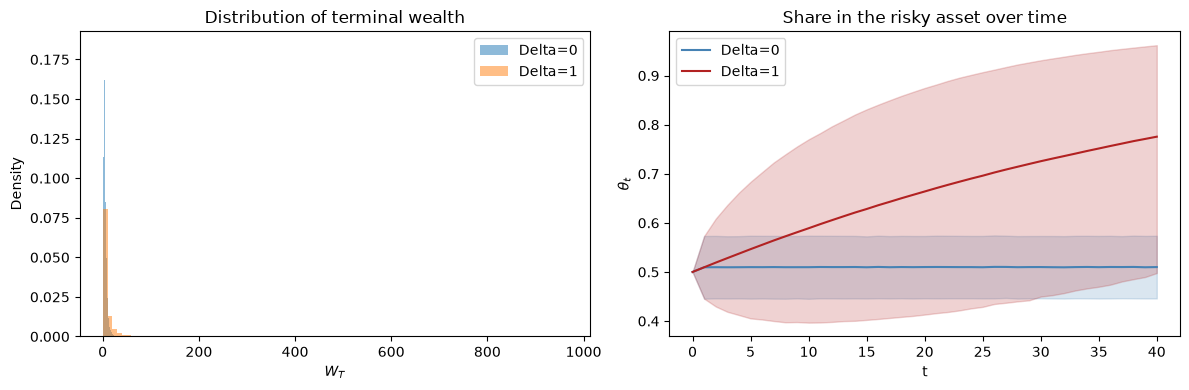

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(model0.sim.W[:, -1], bins=100, alpha=0.5, density=True, label='Delta=0')
axes[0].hist(model1.sim.W[:, -1], bins=100, alpha=0.5, density=True, label='Delta=1')
axes[0].set_xlabel('$W_T$')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of terminal wealth')
axes[0].legend()
t_grid = np.arange(model.par.T + 1)
for m, label, color in [(model0, 'Delta=0', 'steelblue'), (model1, 'Delta=1', 'firebrick')]:
    mean_theta = m.sim.theta.mean(axis=0)
    p10 = np.percentile(m.sim.theta, 10, axis=0)
    p90 = np.percentile(m.sim.theta, 90, axis=0)
    axes[1].plot(t_grid, mean_theta, color=color, label=label)
    axes[1].fill_between(t_grid, p10, p90, color=color, alpha=0.2)
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$\theta_t$')
axes[1].set_title('Share in the risky asset over time')
axes[1].legend()
fig.tight_layout()
plt.show()

**4. Description**

With $\Delta=1$ the portfolio is never traded, so $\theta_t$ drifts away from 0.50. Since the risky asset has a higher expected return than the safe asset ($\mu=0.05 > r=0.01$), $\theta_t$ drifts upward on average, and the 10th-90th percentile band widens over time as the randomness in returns accumulates.

# Question 3: Varying the no-trade band $\Delta$

**1. Table over $\Delta$**
Report the six numbers for each $\Delta$ in one table, with $\tau=0.01$ and the same drawn returns for all of them

In [50]:
Deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]
rows = {}
for Delta in Deltas:
    m = PortfolioModelClass(tau=0.01, Delta=Delta)
    m.simulate(R=R)
    rows[Delta] = m.summary()
table_q3 = pd.DataFrame(rows).T
table_q3.index.name = 'Delta'
table_q3


,n_trades,avg_distance,mean_WT,median_WT,p10_WT,EU
Delta,,,,,,
0.000,39.00000,0.039395,4.962427,4.018396,1.768274,-0.069934
0.025,24.52346,0.039974,4.974622,4.018379,1.769181,-0.069745
0.050,14.33342,0.042948,5.015482,4.035755,1.767369,-0.069505
0.075,8.79048,0.047986,5.073901,4.047645,1.765500,-0.069347
0.100,5.86028,0.054052,5.145886,4.060641,1.759388,-0.069460
0.150,3.15190,0.068029,5.328542,4.104170,1.735272,-0.069950
0.200,1.95026,0.083468,5.559645,4.186286,1.679246,-0.070944
0.300,0.90548,0.117972,6.195680,4.341368,1.536125,-0.073406
1.000,0.00000,0.191138,8.975620,4.447803,1.485479,-0.076690


**2. Figure: trades, distance, and expected utility against $\Delta$**

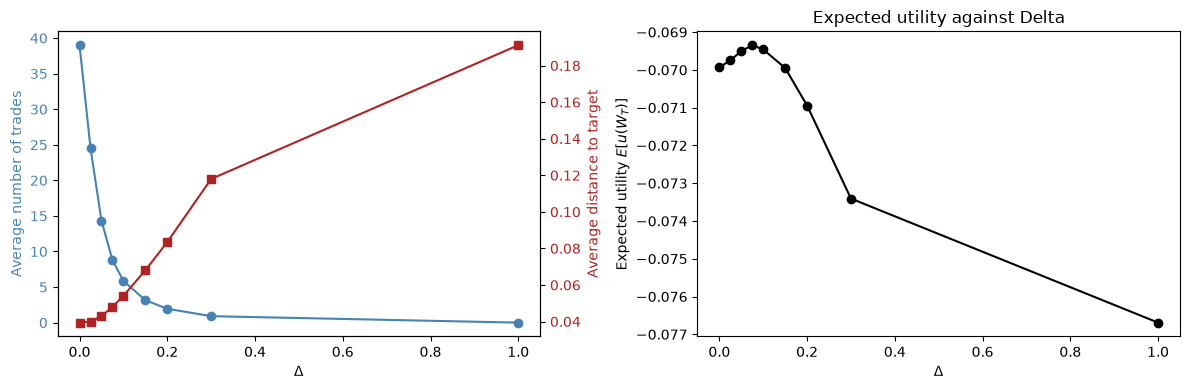

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
ax1.plot(table_q3.index, table_q3['n_trades'], marker='o', color='steelblue', label='Number of trades')
ax1.set_xlabel(r'$\Delta$')
ax1.set_ylabel('Average number of trades', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1b = ax1.twinx()
ax1b.plot(table_q3.index, table_q3['avg_distance'], marker='s', color='firebrick', label='Avg. distance to target')
ax1b.set_ylabel('Average distance to target', color='firebrick')
ax1b.tick_params(axis='y', labelcolor='firebrick')
axes[1].plot(table_q3.index, table_q3['EU'], marker='o', color='black')
axes[1].set_xlabel(r'$\Delta$')
axes[1].set_ylabel('Expected utility $E[u(W_T)]$')
axes[1].set_title('Expected utility against Delta')
fig.tight_layout()
plt.show()

**3. Best $\Delta$**

Which $\Delta$ gives the highest expected utility, and by how much does it beat $\Delta=0$ and $\Delta=1$?

In [52]:
best_Delta = table_q3['EU'].idxmax()
best_EU = table_q3.loc[best_Delta, 'EU']
EU_0 = table_q3.loc[0, 'EU']
EU_1 = table_q3.loc[1, 'EU']
print(f"Best Delta: {best_Delta}")
print(f"EU at best Delta: {best_EU:.6f}")
print(f"Improvement over Delta=0: {best_EU - EU_0:.6f}")
print(f"Improvement over Delta=1: {best_EU - EU_1:.6f}")


Best Delta: 0.075
EU at best Delta: -0.069347
Improvement over Delta=0: 0.000588
Improvement over Delta=1: 0.007343


**4. Description**

As $\Delta$ grows from 0 to the best value (0.075), the **number of trades falls sharply** (from 39.0 to 8.8 per portfolio, a drop of about 77%), while the **average distance to the target rises only modestly** (from 0.039 to 0.048). The wealth statistics barely move over this range: mean $W_T$ rises from 4.96 to 5.07 (+2.3%), median $W_T$ from 4.02 to 4.05, and the 10th percentile is essentially unchanged (1.768 vs. 1.766). Expected utility improves only slightly, from -0.069934 to -0.069347. So going from $\Delta=0$ to the best $\Delta$ saves a large share of the trading costs almost for free, without giving up much precision in tracking the target or much downside protection.

Over the full range up to $\Delta=1$, the picture changes: mean $W_T$ keeps climbing (up to 8.98, i.e. +81% relative to $\Delta=0$), because an untraded portfolio drifts into the risky asset and rides its higher average return, and trading costs disappear entirely. But this comes at the cost of more risk: the 10th percentile of $W_T$ *falls* monotonically as $\Delta$ grows (from 1.77 down to 1.49), and expected utility deteriorates once $\Delta$ passes 0.075, ending up at -0.076690 for $\Delta=1$, clearly worse than the optimum.

Ranking by the **mean** of $W_T$ instead of expected utility would **not** give the same answer: mean $W_T$ increases essentially monotonically in $\Delta$, so it would point to the largest $\Delta$ (never trading) as "best." This is because the mean ignores the downside risk that a risk-averse investor cares about — the CRRA utility with $\gamma=3$ penalizes the low outcomes captured by the falling 10th percentile, which is exactly why expected utility favors a small, disciplined no-trade band around $\Delta=0.075$ rather than letting the portfolio drift unchecked.
